In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import HestonTrainer
from neural_network.config import HestonParams, HestonParamsMulti, ModelConfig
from neural_network.payoff import Put, PutProductMultipleAssets

from heston.tree import HestonTreeFast

In [2]:
exercise_type = "american"

n_assets = 2

S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma_bar = 0.3  # Volatility of variance
v0 = 0.04    # Initial variance

sigma = np.array([0.2, 0.25])  # Volatility of each asset

# Correlation matrix
rho_asset = 0.5
Sigma = np.full((n_assets, n_assets), rho_asset)
np.fill_diagonal(Sigma, 1.0)

rho_cross = [0.3, 0.4]  # Correlation between stock price and variance for each asset

S_min = 0.0
V_min = 0.05
S_max = 3 * S0
V_max = 5 * v0

params = HestonParamsMulti(
    n_assets=n_assets, S0=S0, v0=v0, r=r,
    kappa=kappa, theta=theta, sigma_bar=sigma_bar, sigma=sigma, Sigma=Sigma, rho=rho_cross, K=K, T=T,
    S_min=S_min, S_max=S_max, V_min=V_min, V_max=V_max
)


In [3]:
model_config = ModelConfig(
    input_size=n_assets + 2, # Stock prices + variance + time
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-3,
    dropout=0.2
)

loss_weights = {
    'pde': 4,
    'payoff': 1,
    'S_min': 3,
    'S_max': 1,
    'V_min': 0,
    'V_max': 3,
}

payoff = PutProductMultipleAssets()

In [4]:
heston_trainer = HestonTrainer(model_config, params, payoff, exercise_type, loss_weights, seed=14)

In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-8)

Iteration 0, Loss: 8.152650833129883
Iteration 100, Loss: 0.2564125657081604
Iteration 200, Loss: 0.16602392494678497
Iteration 300, Loss: 0.13385793566703796
Iteration 400, Loss: 0.1091570258140564
Iteration 500, Loss: 0.10035042464733124
Iteration 600, Loss: 0.09728026390075684
Iteration 700, Loss: 0.09201592952013016
Iteration 800, Loss: 0.0879717543721199
Iteration 900, Loss: 0.08137259632349014
Iteration 1000, Loss: 0.07801061123609543
Iteration 1100, Loss: 0.07624655216932297
Iteration 1200, Loss: 0.07168399542570114
Iteration 1300, Loss: 0.06988668441772461
Iteration 1400, Loss: 0.06898879259824753
Iteration 1500, Loss: 0.0645240843296051
Iteration 1600, Loss: 0.06321918964385986
Iteration 1700, Loss: 0.06348913908004761
Iteration 1800, Loss: 0.060586921870708466
Iteration 1900, Loss: 0.06276525557041168
Iteration 2000, Loss: 0.06179448962211609
Iteration 2100, Loss: 0.05988107621669769
Iteration 2200, Loss: 0.06149991601705551
Iteration 2300, Loss: 0.06103641539812088
Early sto

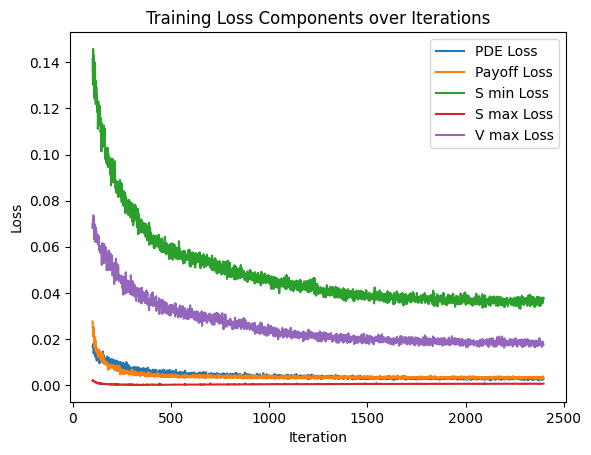

In [6]:
heston_trainer.plot_losses_detailed(start_epoch=100)

In [30]:
S1 = np.linspace(S_min, S_max, 100)
S2 = np.linspace(S_min, S_max, 100)

V = v0

# Create a grid of stock prices
S1_grid, S2_grid = np.meshgrid(S1, S2)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)
t = np.zeros((S_grid.shape[0], 1))  # Time to maturity is 0 at maturity
with torch.no_grad():
    model = heston_trainer.model
    model.eval()
    S_tensor = torch.tensor(S_grid, dtype=torch.float32)
    t_tensor = torch.tensor(t, dtype=torch.float32)
    V_tensor = torch.tensor([[V]], dtype=torch.float32).repeat(S_tensor.shape[0], 1)
    payoffs = model(t_tensor, S_tensor, V_tensor).numpy().reshape(100, 100)

## Reduce to 1D case

In [31]:
A = np.sum(np.square(sigma))
b = Sigma.T @ sigma
B = np.sum(np.square(b))

r_1d = n_assets * r + 0.5 * v0 * (B - A)
kappa_1d = kappa
theta_1d = B * theta
sigma_bar_1d = np.sqrt(B) * sigma_bar


In [32]:
n = 100
mv = 3 * n
mz = 6 * n
V0_min = v0 * 0.25
V0_max = v0 * 3
S0_min = S0 * 0.01
S0_max = S0 * 3

rho = np.mean(rho_cross)

heston_tree = HestonTreeFast(n, mz, mv, K, T, r_1d, kappa_1d, theta_1d, sigma_bar_1d, rho)
heston_tree.build_tree(V0_min=V0_min, V0_max=V0_max, S0_min=S0_min**2, S0_max=S0_max**2,
                       option_type="put", exercise_type="american")

In [34]:
V = v0
S1 = np.linspace(S0_min, S0_max, 100)
S2 = np.linspace(S0_min, S0_max, 100)

# Create a grid of stock prices
S1_grid, S2_grid = np.meshgrid(S1, S2)
S_grid = np.stack([S1_grid, S2_grid], axis=-1).reshape(-1, 2)

S_prod = S_grid[:, 0] * S_grid[:, 1]
t = np.zeros((S_prod.shape[0], 1))  # Time to maturity is 0 at maturity
payoffs_ht = heston_tree.price(V, S_prod, 0).reshape(100, 100)

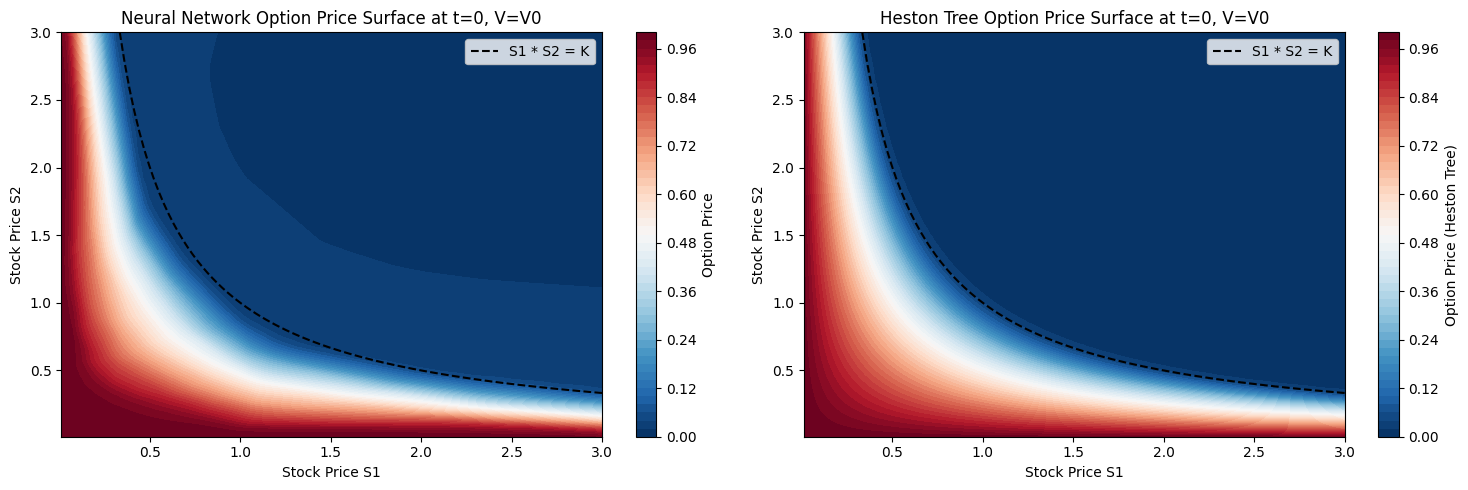

In [35]:
# Plotting the results
Xs = np.linspace(K / S_max, S_max, 100)
Ys = K / Xs

plt.figure(figsize=(15, 5))

# Plot the neural network price surface
plt.subplot(1, 2, 1)
plt.contourf(S1_grid, S2_grid, payoffs, levels=50, cmap='RdBu_r')
plt.colorbar(label='Option Price')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Neural Network Option Price Surface at t=0, V=V0')
plt.legend()

plt.subplot(1, 2, 2)
plt.contourf(S1_grid, S2_grid, payoffs_ht, levels=50, cmap='RdBu_r')
plt.colorbar(label='Option Price (Heston Tree)')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Heston Tree Option Price Surface at t=0, V=V0')
plt.legend()

plt.tight_layout()
plt.show()

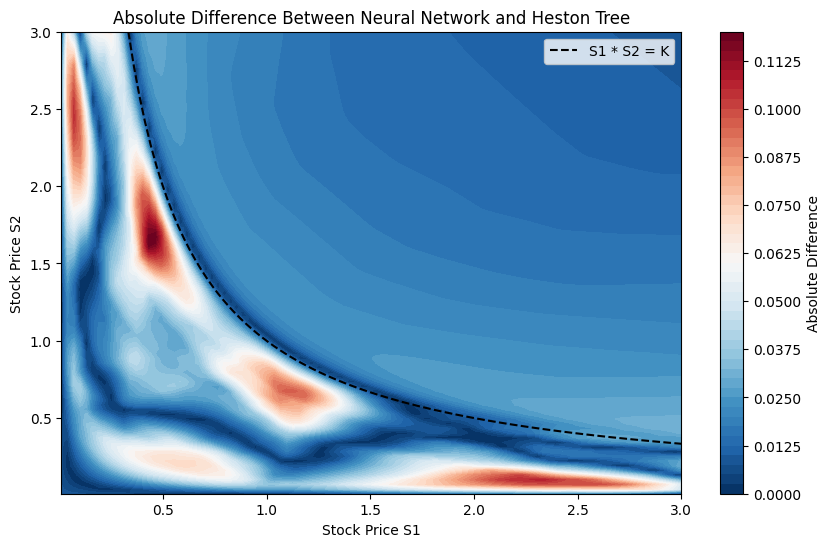

In [36]:
diff = np.abs(payoffs - payoffs_ht)

plt.figure(figsize=(10, 6))
plt.contourf(S1_grid, S2_grid, diff, levels=50, cmap='RdBu_r')
plt.colorbar(label='Absolute Difference')
plt.plot(Xs, Ys, color='black', linestyle='--', label='S1 * S2 = K')
plt.xlabel('Stock Price S1')
plt.ylabel('Stock Price S2')
plt.title('Absolute Difference Between Neural Network and Heston Tree')
plt.legend()
plt.show()

In [37]:
# Along strike price
resolution = 100
S1_vals = np.linspace(K / S_max, S_max, resolution)
S2_vals = K / S1_vals

ht_prices_strike = heston_trainer.predict(np.zeros((resolution, 1)), S1_vals, S2_vals, np.full((resolution, 1), v0)).detach().numpy().flatten()
tree_price_strike = heston_tree.price(v0, S1_vals * S2_vals, 0)

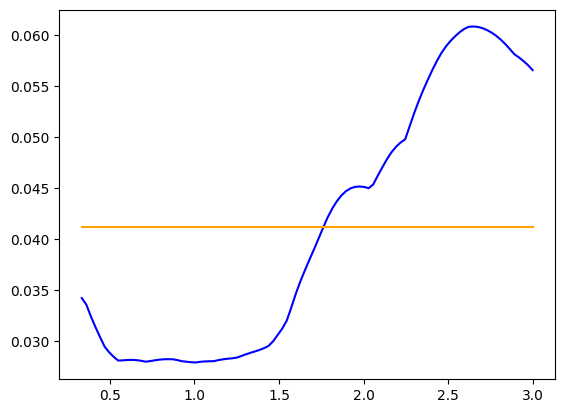

In [38]:
plt.plot(S1_vals, ht_prices_strike, label='Neural Network', color='blue')
plt.plot(S1_vals, tree_price_strike, label='Heston Tree', color='orange')
plt.show()

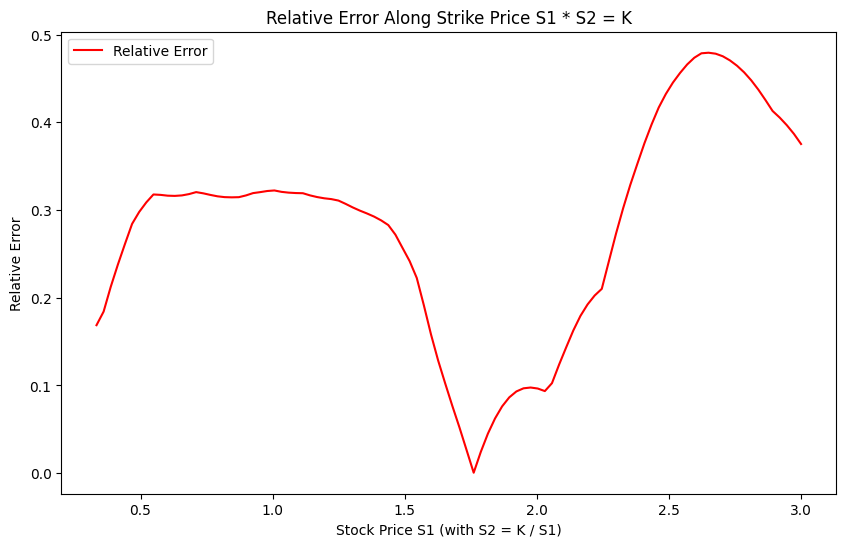

In [39]:
relative_error_strike = np.abs(ht_prices_strike - tree_price_strike) / np.maximum(tree_price_strike, 1e-8)
plt.figure(figsize=(10, 6))
plt.plot(S1_vals, relative_error_strike, label='Relative Error', color='red')
plt.xlabel('Stock Price S1 (with S2 = K / S1)')
plt.ylabel('Relative Error')
plt.title('Relative Error Along Strike Price S1 * S2 = K')
plt.legend()
plt.show()